# 03 - Eksperimen CNN (Skenario 10-11)

MobileNetV2 two-stage fine-tuning, Grad-CAM, McNemar vs S5.
- **S10** = SSR + E* + segmentasi (full pipeline klasik, diganti CNN)
- **S11** = tanpa restorasi, tanpa enhancement (baseline murni CNN vs S1 klasik)

In [1]:
# ============================================================
# Setup cell - Kaggle Notebooks (Kaggle-only). Jalankan PALING ATAS.
# Cara attach dataset: panel kanan > + Add Data > cari
#   'fruit and vegetable disease healthy vs rotten' > Add.
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import sys
import shutil
import subprocess
from pathlib import Path

# 1. Clone repo dari GitHub (atau pull jika sudah ada di sesi ini)
REPO_URL = "https://github.com/faizhuda/pcd-kelompok-17.git"
PROJECT_DIR = Path("/kaggle/working/pcd-kelompok-17")
if not PROJECT_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=False)

# 2. Working directory ke root project + tambah ke sys.path
os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

# 3. Dependency inti SUDAH pre-installed di Kaggle -> tidak ada pip install.

# 4. Dataset gambar (read-only, hasil + Add Data)
# Auto-detect: Kaggle bisa mount di /kaggle/input/<slug> atau
# /kaggle/input/datasets/<user>/<slug> tergantung cara attach.
_DATASET_SLUG = 'fruit-and-vegetable-disease-healthy-vs-rotten'
_candidates = [
    Path('/kaggle/input') / _DATASET_SLUG,
    Path('/kaggle/input/datasets/muhammad0subhan') / _DATASET_SLUG,
]
RAW_DATA_DIR = next((p for p in _candidates if p.exists()), None)
if RAW_DATA_DIR is None:
    # Fallback: cari folder mana saja di /kaggle/input yang berisi gambar dataset
    for _p in Path('/kaggle/input').rglob(_DATASET_SLUG):
        if _p.is_dir():
            RAW_DATA_DIR = _p
            break
assert RAW_DATA_DIR is not None, "Dataset belum di-attach. + Add Data > cari dataset > Add."

# 5. Auto-restore hasil notebook sebelumnya (untuk notebook 03 & 04).
#    Attach output run lama via: + Add Data > Your Work / Dataset bersama.
def restore_previous_outputs():
    # Kaggle mounts notebook outputs di /kaggle/input/notebooks/<user>/<notebook>/
    # sehingga perlu rglob, bukan glob satu level.
    restored = []
    for repo in Path("/kaggle/input").rglob("pcd-kelompok-17"):
        if not repo.is_dir():
            continue
        for sub in ("results", "data/processed"):
            src_dir = repo / sub
            if src_dir.exists():
                shutil.copytree(src_dir, PROJECT_DIR / sub, dirs_exist_ok=True)
                restored.append(str(src_dir))
    return restored

restored = restore_previous_outputs()
print("Project :", PROJECT_DIR)
print("Dataset :", RAW_DATA_DIR)
print("Restore :", restored or "(mulai dari nol)")


Cloning into '/kaggle/working/pcd-kelompok-17'...


Project : /kaggle/working/pcd-kelompok-17
Dataset : /kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten
Restore : ['/kaggle/input/notebooks/faiznaufalhuda/pcd-02-classical/pcd-kelompok-17/results', '/kaggle/input/notebooks/faiznaufalhuda/pcd-02-classical/pcd-kelompok-17/data/processed']


In [2]:
import os
import sys
from pathlib import Path

# Setup cell sudah chdir ke PROJECT_DIR & menambah sys.path (Kaggle-only).
ROOT = Path("/kaggle/working/pcd-kelompok-17")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

from src.evaluate import (
    append_significance_test,
    compute_metrics,
    make_gradcam_heatmap,
    mcnemar_test,
    plot_confusion_matrix,
    plot_gradcam,
    save_scenario_metrics,
)
from src.models import (
    build_mobilenetv2,
    compile_mobilenet,
    get_mobilenet_callbacks,
    unfreeze_last_layers,
)
from src.pipeline import image_to_cnn_input, process_image
from src.utils import build_dataset_index, get_project_paths, make_splits, read_best_enhancement, set_seed

set_seed(42)
paths = get_project_paths()
# Split di-regenerate dari dataset (deterministik) - identik dengan notebook 01/02
# RAW_DATA_DIR sudah di-set setup cell (auto-detect path Kaggle)
train_df, val_df, test_df = make_splits(build_dataset_index(RAW_DATA_DIR))
enhancement = read_best_enhancement(paths["metrics"])
print(f"Menggunakan enhancement E*: {enhancement}")


E0000 00:00:1780811781.034229      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780811781.092350      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780811781.545373      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780811781.545424      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780811781.545428      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780811781.545431      23 computation_placer.cc:177] computation placer already registered. Please check linka

Menggunakan enhancement E*: clahe


In [3]:
# Cache preprocessing ke disk (SSR + segmentasi dihitung sekali, bukan per epoch).
CACHE_DIR = Path('/kaggle/temp/tfcache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def make_dataset(df, batch_size=32, shuffle=False,
                 restoration='ssr', do_segment=True,
                 enhancement_method=None, cache_name=None):
    if enhancement_method is None:
        enhancement_method = enhancement
    def generator():
        label_map = {"fresh": 0, "rotten": 1}
        for _, row in df.iterrows():
            out = process_image(
                path=row["filepath"],
                restoration=restoration,
                enhancement=enhancement_method,
                do_segment=do_segment,
            )
            if out["img"] is None:
                continue
            x = image_to_cnn_input(out["img"])[0]
            y = np.zeros(2, dtype=np.float32)
            y[label_map[row['label']]] = 1.0
            yield x, y

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(2,), dtype=tf.float32),
        )
    )
    if cache_name is not None:
        dataset = dataset.cache(str(CACHE_DIR / cache_name))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=2048, seed=42, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# S10: SSR + E* + segmentasi (identik dengan S5 klasik, tapi CNN)
train_ds_s10 = make_dataset(train_df, shuffle=True, restoration='ssr', do_segment=True, cache_name='train_s10')
val_ds_s10   = make_dataset(val_df,   restoration='ssr', do_segment=True, cache_name='val_s10')
test_ds_s10  = make_dataset(test_df,  restoration='ssr', do_segment=True, cache_name='test_s10')

# S11: tanpa restorasi, tanpa enhancement, tanpa segmentasi (baseline murni CNN)
train_ds_s11 = make_dataset(train_df, shuffle=True, restoration='none', do_segment=False, enhancement_method='none', cache_name='train_s11')
val_ds_s11   = make_dataset(val_df,   restoration='none', do_segment=False, enhancement_method='none', cache_name='val_s11')
test_ds_s11  = make_dataset(test_df,  restoration='none', do_segment=False, enhancement_method='none', cache_name='test_s11')


I0000 00:00:1780811832.042164      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
y_train_labels = train_df["label"].map({"fresh": 0, "rotten": 1}).values
classes = np.unique(y_train_labels)
weights = compute_class_weight("balanced", classes=classes, y=y_train_labels)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
class_weight


{0: 1.0622215314475183, 1: 0.9446645779579801}

## Skenario 10: CNN - SSR + E* + Segmentasi (mirror S5)

### Stage 1 - Base frozen (20 epoch)

In [5]:
model_s10 = build_mobilenetv2(num_classes=2)
model_s10 = compile_mobilenet(model_s10, learning_rate=1e-4)
cb_s10 = get_mobilenet_callbacks(str(paths["models"] / "mobilenetv2_s10_stage1.h5"))

history1_s10 = model_s10.fit(
    train_ds_s10, validation_data=val_ds_s10, epochs=20,
    class_weight=class_weight, callbacks=cb_s10,
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


I0000 00:00:1780811891.257669      77 service.cc:152] XLA service 0x7bce20003c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780811891.257726      77 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780811892.549549      77 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780811899.338417      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    641/Unknown 519s 710ms/step - accuracy: 0.7462 - loss: 0.5099

641/641 ━━━━━━━━━━━━━━━━━━━━ 634s 890ms/step - accuracy: 0.8253 - loss: 0.3782 - val_accuracy: 0.9040 - val_loss: 0.2451 - learning_rate: 1.0000e-04
Epoch 2/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9058 - loss: 0.2353

641/641 ━━━━━━━━━━━━━━━━━━━━ 48s 67ms/step - accuracy: 0.9127 - loss: 0.2203 - val_accuracy: 0.9197 - val_loss: 0.1987 - learning_rate: 1.0000e-04
Epoch 3/20
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9336 - loss: 0.1785

...

641/641 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9814 - loss: 0.0578 - val_accuracy: 0.9627 - val_loss: 0.1020 - learning_rate: 1.0000e-04
Epoch 12/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9850 - loss: 0.0504 - val_accuracy: 0.9618 - val_loss: 0.1041 - learning_rate: 1.0000e-04
Epoch 13/20
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9848 - loss: 0.0475

641/641 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9865 - loss: 0.0456 - val_accuracy: 0.9636 - val_loss: 0.0989 - learning_rate: 1.0000e-04
Epoch 14/20
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9882 - loss: 0.0391

641/641 ━━━━━━━━━━━━━━━━━━━━ 46s 69ms/step - accuracy: 0.9882 - loss: 0.0396 - val_accuracy: 0.9656 - val_loss: 0.0946 - learning_rate: 1.0000e-04
Epoch 15/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.9902 - loss: 0.0360 - val_accuracy: 0.9665 - val_loss: 0.0963 - learning_rate: 1.0000e-04
Epoch 16/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.9917 - loss: 0.0308 - val_accuracy: 0.9647 - val_loss: 0.0986 - learning_rate: 1.0000e-04
Epoch 17/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.9932 - loss: 0.0278 - val_accuracy: 0.9654 - val_loss: 0.0969 - learning_rate: 1.0000e-04
Epoch 18/20
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9937 - loss: 0.0253

641/641 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.9946 - loss: 0.0235 - val_accuracy: 0.9675 - val_loss: 0.0939 - learning_rate: 5.0000e-05
Epoch 19/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 59s 85ms/step - accuracy: 0.9956 - loss: 0.0209 - val_accuracy: 0.9677 - val_loss: 0.0951 - learning_rate: 5.0000e-05
Epoch 20/20
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9955 - loss: 0.0206

641/641 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.9957 - loss: 0.0205 - val_accuracy: 0.9679 - val_loss: 0.0933 - learning_rate: 5.0000e-05


### Stage 2 - Fine-tune 20 lapisan terakhir (50 epoch)

In [6]:
model_s10 = unfreeze_last_layers(model_s10, n=20)
model_s10 = compile_mobilenet(model_s10, learning_rate=1e-5)
cb2_s10 = get_mobilenet_callbacks(str(paths["models"] / "mobilenetv2_s10_stage2.h5"))

history2_s10 = model_s10.fit(
    train_ds_s10, validation_data=val_ds_s10, epochs=50,
    class_weight=class_weight, callbacks=cb2_s10,
)


Epoch 1/50
    641/Unknown 53s 50ms/step - accuracy: 0.9364 - loss: 0.1666

641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9463 - loss: 0.1350 - val_accuracy: 0.9524 - val_loss: 0.1308 - learning_rate: 1.0000e-05
Epoch 2/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9703 - loss: 0.0779

641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9720 - loss: 0.0730 - val_accuracy: 0.9624 - val_loss: 0.1074 - learning_rate: 1.0000e-05
Epoch 3/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9778 - loss: 0.0592

641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9782 - loss: 0.0577 - val_accuracy: 0.9672 - val_loss: 0.0930 - learning_rate: 1.0000e-05
Epoch 4/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9836 - loss: 0.0471

641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9847 - loss: 0.0454 - val_accuracy: 0.9693 - val_loss: 0.0862 - learning_rate: 1.0000e-05
Epoch 5/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9883 - loss: 0.0357

...

641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9916 - loss: 0.0284 - val_accuracy: 0.9718 - val_loss: 0.0809 - learning_rate: 1.0000e-05
Epoch 7/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9926 - loss: 0.0241 - val_accuracy: 0.9722 - val_loss: 0.0822 - learning_rate: 1.0000e-05
Epoch 8/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9946 - loss: 0.0200

641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9947 - loss: 0.0203 - val_accuracy: 0.9722 - val_loss: 0.0795 - learning_rate: 1.0000e-05
Epoch 9/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9942 - loss: 0.0176

641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9948 - loss: 0.0168 - val_accuracy: 0.9745 - val_loss: 0.0749 - learning_rate: 1.0000e-05
Epoch 10/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9957 - loss: 0.0154 - val_accuracy: 0.9752 - val_loss: 0.0767 - learning_rate: 1.0000e-05
Epoch 11/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9967 - loss: 0.0129

641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9966 - loss: 0.0126 - val_accuracy: 0.9752 - val_loss: 0.0748 - learning_rate: 1.0000e-05
Epoch 12/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9971 - loss: 0.0112

641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9972 - loss: 0.0107 - val_accuracy: 0.9766 - val_loss: 0.0726 - learning_rate: 1.0000e-05
Epoch 13/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9973 - loss: 0.0097 - val_accuracy: 0.9775 - val_loss: 0.0729 - learning_rate: 1.0000e-05
Epoch 14/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.9979 - loss: 0.0086 - val_accuracy: 0.9779 - val_loss: 0.0748 - learning_rate: 1.0000e-05
Epoch 15/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 52s 78ms/step - accuracy: 0.9980 - loss: 0.0082 - val_accuracy: 0.9784 - val_loss: 0.0810 - learning_rate: 1.0000e-05
Epoch 16/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 38s 52ms/step - accuracy: 0.9979 - loss: 0.0070 - val_accuracy: 0.9782 - val_loss: 0.0767 - learning_rate: 5.0000e-06
Epoch 17/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 54s 81ms/step - accuracy: 0.9988 - loss: 0.0059 - val_accuracy: 0.9775 - val_loss: 0.0754 - learning_rate: 5.0000e-06


### Evaluasi Skenario 10

{'accuracy': 0.9829312699135184,
 'precision_weighted': 0.9829607034474858,
 'recall_weighted': 0.9829312699135184,
 'f1_weighted': 0.9829345021930658}

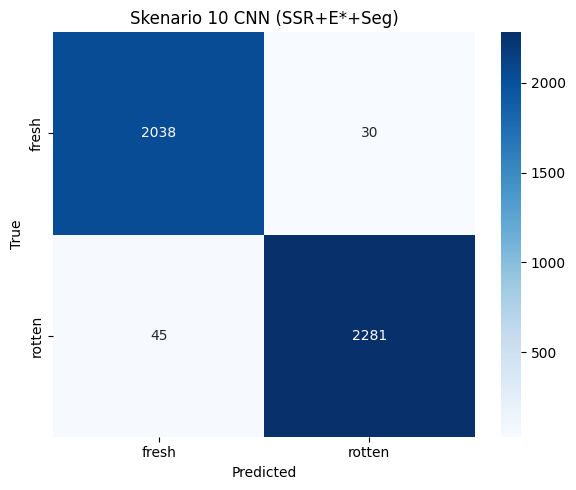

In [7]:
import time

# Collect valid rows during the evaluation loop (avoids a second
# full-dataset reprocessing pass that the old code did).
y_true_list, y_pred_list = [], []
valid_rows_s10 = []
t0 = time.perf_counter()
n = 0
for x_batch, y_batch in test_ds_s10:
    preds = model_s10.predict_on_batch(x_batch)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(y_batch.numpy(), axis=1))
    n += len(y_batch)

infer_ms = (time.perf_counter() - t0) * 1000 / max(n, 1)
y_true_s10 = np.array(y_true_list)
y_pred_s10 = np.array(y_pred_list)
metrics_s10 = compute_metrics(y_true_s10, y_pred_s10)
save_scenario_metrics(
    10, enhancement, True, "cnn", "MobileNetV2",
    metrics_s10, infer_ms, len(y_true_s10), paths["metrics"], restoration="ssr",
)
# Build predictions CSV from test_df rows that match valid S10 generator order.
# The generator skips rows where process_image returns None; replicate same logic.
# Guarded: a length mismatch must NOT crash here (this cell runs BEFORE S11
# training, so a crash would waste the whole CNN run).
valid_rows_s10 = [
    row for _, row in test_df.iterrows()
    if process_image(row['filepath'], restoration='ssr', enhancement=enhancement, do_segment=True)['img'] is not None
]
if len(valid_rows_s10) == len(y_pred_s10):
    pred_df_s10 = pd.DataFrame(valid_rows_s10).reset_index(drop=True)
    pred_df_s10['pred'] = y_pred_s10
    pred_df_s10.to_csv(paths['metrics'] / 'predictions_s10.csv', index=False)
else:
    print(f'[WARN] predictions_s10 dilewati: {len(valid_rows_s10)} baris vs {len(y_pred_s10)} prediksi')
plot_confusion_matrix(y_true_s10, y_pred_s10, title="Skenario 10 CNN (SSR+E*+Seg)",
                      save_path=paths["figures_confusion"] / "scenario_10.png")
metrics_s10


## Skenario 11: CNN - Tanpa Restorasi, Tanpa Enhancement (mirror S1)

### Stage 1 - Base frozen (20 epoch)

In [8]:
model_s11 = build_mobilenetv2(num_classes=2)
model_s11 = compile_mobilenet(model_s11, learning_rate=1e-4)
cb_s11 = get_mobilenet_callbacks(str(paths["models"] / "mobilenetv2_s11_stage1.h5"))

history1_s11 = model_s11.fit(
    train_ds_s11, validation_data=val_ds_s11, epochs=20,
    class_weight=class_weight, callbacks=cb_s11,
)


Epoch 1/20
    641/Unknown 298s 405ms/step - accuracy: 0.8035 - loss: 0.4212

641/641 ━━━━━━━━━━━━━━━━━━━━ 364s 509ms/step - accuracy: 0.8750 - loss: 0.2988 - val_accuracy: 0.9354 - val_loss: 0.1741 - learning_rate: 1.0000e-04
Epoch 2/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9346 - loss: 0.1736

641/641 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.9421 - loss: 0.1594 - val_accuracy: 0.9536 - val_loss: 0.1290 - learning_rate: 1.0000e-04
Epoch 3/20
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9539 - loss: 0.1241

641/641 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.9570 - loss: 0.1186 - val_accuracy: 0.9579 - val_loss: 0.1161 - learning_rate: 1.0000e-04
Epoch 4/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9646 - loss: 0.1014

641/641 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.9678 - loss: 0.0940 - val_accuracy: 0.9663 - val_loss: 0.0925 - learning_rate: 1.0000e-04
Epoch 5/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9704 - loss: 0.0825

...

641/641 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.9857 - loss: 0.0466 - val_accuracy: 0.9786 - val_loss: 0.0676 - learning_rate: 1.0000e-04
Epoch 9/20
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9870 - loss: 0.0414

641/641 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.9877 - loss: 0.0405 - val_accuracy: 0.9784 - val_loss: 0.0646 - learning_rate: 1.0000e-04
Epoch 10/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.9898 - loss: 0.0349 - val_accuracy: 0.9793 - val_loss: 0.0649 - learning_rate: 1.0000e-04
Epoch 11/20
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9902 - loss: 0.0335

641/641 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.9909 - loss: 0.0315 - val_accuracy: 0.9795 - val_loss: 0.0616 - learning_rate: 1.0000e-04
Epoch 12/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9919 - loss: 0.0278

641/641 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.9924 - loss: 0.0268 - val_accuracy: 0.9807 - val_loss: 0.0596 - learning_rate: 1.0000e-04
Epoch 13/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.9938 - loss: 0.0232 - val_accuracy: 0.9813 - val_loss: 0.0598 - learning_rate: 1.0000e-04
Epoch 14/20
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9955 - loss: 0.0190

641/641 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.9949 - loss: 0.0198 - val_accuracy: 0.9822 - val_loss: 0.0582 - learning_rate: 1.0000e-04
Epoch 15/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.9958 - loss: 0.0179 - val_accuracy: 0.9818 - val_loss: 0.0588 - learning_rate: 1.0000e-04
Epoch 16/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.9961 - loss: 0.0162 - val_accuracy: 0.9816 - val_loss: 0.0584 - learning_rate: 1.0000e-04
Epoch 17/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.9973 - loss: 0.0132 - val_accuracy: 0.9822 - val_loss: 0.0584 - learning_rate: 1.0000e-04
Epoch 18/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.9976 - loss: 0.0112 - val_accuracy: 0.9822 - val_loss: 0.0596 - learning_rate: 5.0000e-05
Epoch 19/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.9982 - loss: 0.0097 - val_accuracy: 0.9820 - val_loss: 0.0585 - learning_rate: 5.0000e-05


### Stage 2 - Fine-tune 20 lapisan terakhir (50 epoch)

In [9]:
model_s11 = unfreeze_last_layers(model_s11, n=20)
model_s11 = compile_mobilenet(model_s11, learning_rate=1e-5)
cb2_s11 = get_mobilenet_callbacks(str(paths["models"] / "mobilenetv2_s11_stage2.h5"))

history2_s11 = model_s11.fit(
    train_ds_s11, validation_data=val_ds_s11, epochs=50,
    class_weight=class_weight, callbacks=cb2_s11,
)


Epoch 1/50
    641/Unknown 76s 86ms/step - accuracy: 0.9404 - loss: 0.1620

641/641 ━━━━━━━━━━━━━━━━━━━━ 92s 111ms/step - accuracy: 0.9535 - loss: 0.1237 - val_accuracy: 0.9599 - val_loss: 0.1176 - learning_rate: 1.0000e-05
Epoch 2/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9774 - loss: 0.0627

641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 91ms/step - accuracy: 0.9758 - loss: 0.0642 - val_accuracy: 0.9690 - val_loss: 0.0977 - learning_rate: 1.0000e-05
Epoch 3/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9852 - loss: 0.0423

641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.9858 - loss: 0.0402 - val_accuracy: 0.9768 - val_loss: 0.0750 - learning_rate: 1.0000e-05
Epoch 4/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9871 - loss: 0.0375

641/641 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.9874 - loss: 0.0371 - val_accuracy: 0.9813 - val_loss: 0.0616 - learning_rate: 1.0000e-05
Epoch 5/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9928 - loss: 0.0244

641/641 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9825 - val_loss: 0.0592 - learning_rate: 1.0000e-05
Epoch 6/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9924 - loss: 0.0235

641/641 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.9854 - val_loss: 0.0520 - learning_rate: 1.0000e-05
Epoch 7/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9944 - loss: 0.0177

641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.9952 - loss: 0.0164 - val_accuracy: 0.9863 - val_loss: 0.0494 - learning_rate: 1.0000e-05
Epoch 8/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.9965 - loss: 0.0124 - val_accuracy: 0.9854 - val_loss: 0.0538 - learning_rate: 1.0000e-05
Epoch 9/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.9971 - loss: 0.0116 - val_accuracy: 0.9848 - val_loss: 0.0596 - learning_rate: 1.0000e-05
Epoch 10/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.9972 - loss: 0.0094 - val_accuracy: 0.9870 - val_loss: 0.0513 - learning_rate: 1.0000e-05
Epoch 11/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.9976 - loss: 0.0091 - val_accuracy: 0.9870 - val_loss: 0.0495 - learning_rate: 5.0000e-06
Epoch 12/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9982 - loss: 0.0078

641/641 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.9984 - loss: 0.0070 - val_accuracy: 0.9870 - val_loss: 0.0489 - learning_rate: 5.0000e-06
Epoch 13/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.9982 - loss: 0.0063 - val_accuracy: 0.9873 - val_loss: 0.0496 - learning_rate: 5.0000e-06
Epoch 14/50
639/641 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9981 - loss: 0.0062

641/641 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.9982 - loss: 0.0059 - val_accuracy: 0.9886 - val_loss: 0.0466 - learning_rate: 5.0000e-06
Epoch 15/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.9985 - loss: 0.0056 - val_accuracy: 0.9868 - val_loss: 0.0522 - learning_rate: 5.0000e-06
Epoch 16/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.9987 - loss: 0.0052 - val_accuracy: 0.9873 - val_loss: 0.0510 - learning_rate: 5.0000e-06
Epoch 17/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.9868 - val_loss: 0.0514 - learning_rate: 5.0000e-06
Epoch 18/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 0.9875 - val_loss: 0.0493 - learning_rate: 2.5000e-06
Epoch 19/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9879 - val_loss: 0.0488 - learning_rate: 2.5000e-06


### Evaluasi Skenario 11

{'accuracy': 0.987938097405553,
 'precision_weighted': 0.987965752375415,
 'recall_weighted': 0.987938097405553,
 'f1_weighted': 0.9879403815497665}

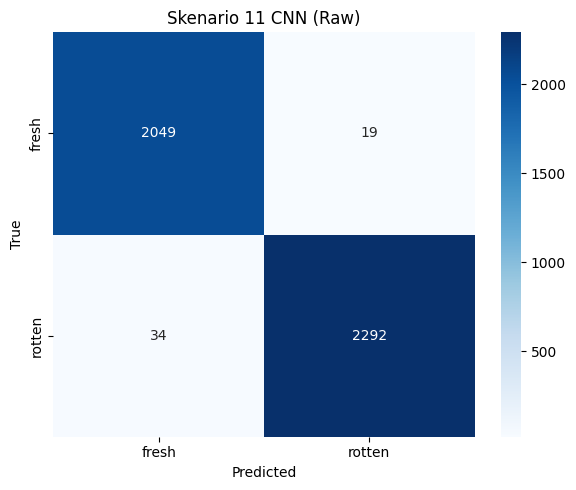

In [10]:
y_true_list, y_pred_list = [], []
t0 = time.perf_counter()
n = 0
for x_batch, y_batch in test_ds_s11:
    preds = model_s11.predict_on_batch(x_batch)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(y_batch.numpy(), axis=1))
    n += len(y_batch)

infer_ms = (time.perf_counter() - t0) * 1000 / max(n, 1)
y_true_s11 = np.array(y_true_list)
y_pred_s11 = np.array(y_pred_list)
metrics_s11 = compute_metrics(y_true_s11, y_pred_s11)
save_scenario_metrics(
    11, "none", False, "cnn", "MobileNetV2",
    metrics_s11, infer_ms, len(y_true_s11), paths["metrics"], restoration="none",
)
plot_confusion_matrix(y_true_s11, y_pred_s11, title="Skenario 11 CNN (Raw)",
                      save_path=paths["figures_confusion"] / "scenario_11.png")
metrics_s11


## McNemar Significance Tests (dijalankan sebelum Grad-CAM)


In [11]:
# McNemar bersifat SUPLEMENTER: metrik utama S10/S11 sudah tersimpan di sel
# sebelumnya. Seluruh blok dibungkus try/except agar error tak terduga di sini
# TIDAK memblokir Grad-CAM (traceback tetap dicetak supaya terlihat).
import traceback
import joblib

def _safe_mcnemar(name, a, b, y_t, p_a, p_b):
    # Guard panjang: McNemar butuh prediksi paired pada sampel yang sama.
    if len(p_a) != len(y_t) or len(p_b) != len(y_t):
        print(f'[SKIP {name}] panjang beda: y_true={len(y_t)}, {a}={len(p_a)}, {b}={len(p_b)}')
        return
    stat, pval, concl = mcnemar_test(y_t, p_a, p_b)
    append_significance_test(name, a, b, stat, pval, concl, paths['metrics'])
    print(f'{name}:', stat, pval, concl)

s5_path = paths['models'] / 'svm_scenario_05.pkl'
try:
    if not s5_path.exists():
        raise FileNotFoundError('svm_scenario_05.pkl tidak ada - jalankan nb02 dulu.')
    from src.experiments import extract_split_matrix
    from src.models import build_svm_pipeline
    enh = read_best_enhancement(paths['metrics'])

    # S5 (SVM full): fitur SSR+E*+seg+all - cache HIT dari nb02 (split_name='test').
    s5_model = joblib.load(s5_path)
    X_test_s5, _, _ = extract_split_matrix(
        test_df, enh, True, 'all', paths['data_processed'], split_name='test', restoration='ssr')
    y_pred_s5 = s5_model.predict(X_test_s5)

    # S1 (SVM raw): re-train cepat. PENTING - pakai y yang DIKEMBALIKAN extract
    # (label baris valid), bukan label_encode(train_df) penuh; kalau ada citra
    # tak terbaca panjangnya beda dan fit() akan crash.
    X_train_s1, y_train_s1, _ = extract_split_matrix(
        train_df, 'none', False, 'all', paths['data_processed'], split_name='train', restoration='none')
    X_test_s1, _, _ = extract_split_matrix(
        test_df, 'none', False, 'all', paths['data_processed'], split_name='test', restoration='none')
    s1_model = build_svm_pipeline()
    s1_model.fit(X_train_s1, y_train_s1)
    y_pred_s1 = s1_model.predict(X_test_s1)

    _safe_mcnemar('S10 vs S5 (CNN vs SVM)', 'S10', 'S5', y_true_s10, y_pred_s10, y_pred_s5)
    _safe_mcnemar('S11 vs S1 (CNN-raw vs SVM-raw)', 'S11', 'S1', y_true_s11, y_pred_s11, y_pred_s1)
    _safe_mcnemar('S10 vs S11 (full vs raw CNN)', 'S10', 'S11', y_true_s10, y_pred_s10, y_pred_s11)
except Exception:
    print('[McNemar dilewati karena error - metrik utama S10/S11 tetap aman]')
    traceback.print_exc()


S10 vs S5 (CNN vs SVM): 70.33196721311475 5.0118909082439964e-17 signifikan
S11 vs S1 (CNN-raw vs SVM-raw): 37.751633986928105 8.03493885577273e-10 signifikan
S10 vs S11 (full vs raw CNN): 5.95945945945946 0.014638528457408349 signifikan


## Grad-CAM (Skenario 10 - CNN full pipeline)

In [12]:
import matplotlib.pyplot as plt

gradcam_dir = paths["figures_gradcam"]
gradcam_dir.mkdir(parents=True, exist_ok=True)
representative = ["Apple", "Banana", "Tomato"]

for commodity in representative:
    for label in ["fresh", "rotten"]:
        subset = test_df[
            (test_df["commodity"].str.contains(commodity, case=False, na=False)) &
            (test_df["label"] == label)
        ]
        if subset.empty:
            subset = test_df[test_df["label"] == label].head(3)
        for _, row in subset.head(3).iterrows():
            out = process_image(
                path=row["filepath"], restoration="ssr",
                enhancement=enhancement, do_segment=True,
            )
            if out["img"] is None:
                continue
            x = image_to_cnn_input(out["img"])
            heatmap = make_gradcam_heatmap(model_s10, x)
            fname = Path(row["filepath"]).stem
            save = gradcam_dir / f"{commodity}_{label}_{fname}.png"
            plot_gradcam(out["img"], heatmap, save_path=save)
            plt.close("all")
